In [ ]:
!pip install pandas
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/Fuel Consumption Ratings 2023.csv', encoding='latin1')
print("Archivo CSV cargado exitosamente.")


Archivo CSV cargado exitosamente.


In [ ]:
df = pd.read_csv("/content/Fuel Consumption Ratings 2023.csv", encoding='latin1')
df.head()

,Year,Make,Model,Vehicle Class,Engine Size (L),Cylinders,Transmission,Fuel Type,Fuel Consumption (L/100Km),Hwy (L/100 km),Comb (L/100 km),Comb (mpg),CO2 Emissions (g/km),CO2 Rating,Smog Rating
0,2023,Acura,Integra,Full-size,1.5,4.0,AV7,Z,7.9,6.3,7.2,39.0,167.0,6.0,7.0
1,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,AV7,Z,8.1,6.5,7.4,38.0,172.0,6.0,7.0
2,2023,Acura,Integra A-SPEC,Full-size,1.5,4.0,M6,Z,8.9,6.5,7.8,36.0,181.0,6.0,6.0
3,2023,Acura,MDX SH-AWD,SUV: Small,3.5,6.0,AS10,Z,12.6,9.4,11.2,25.0,263.0,4.0,5.0
4,2023,Acura,MDX SH-AWD Type S,SUV: Standard,3.0,6.0,AS10,Z,13.8,11.2,12.4,23.0,291.0,4.0,5.0


# 💡 Aclaración: Descubrimos que se puede utilizar emojis y nos pareció una forma mas bonita de mostrar la información

## 📊 Descripción del Dataset

El dataset contiene múltiples **variables independientes**, entre las que se incluyen:

- 📅 Año del modelo  
- 🏭 Fabricante  
- 🚗 Modelo específico  
- 🚙 Clase del vehículo  
- ⚙️ Tamaño del motor  
- 🔢 Número de cilindros  
- 🔁 Tipo de transmisión  
- ⛽ Tipo de combustible  

Por otro lado, cuenta con diversas **variables dependientes**, como:

- 🏙️ Consumo de combustible en ciudad  
- 🛣️ Consumo de combustible en carretera  
- ⚖️ Consumo combinado  
  - 🔸 En millas por galón (MPG)  
  - 🔸 En litros por cada 100 kilómetros (L/100km)
- 🌿 Clasificación de CO₂  
- 🌫️ Clasificación de smog  

> 🔍 **Variable dependiente principal:**  
> **Emisiones de dióxido de carbono (CO₂) en gramos por kilómetro**, ya que representa el impacto ambiental directo de cada vehículo.


El dataset cuenta con 834 muestras



## 📈 Análisis de Correlación con la Variable de Salida


\**Las caracteristicas que seguramente guardan mayor relacion con la variable dependiente son:**
- ⚙️ Tamaño del motor  
- 🔢 Número de cilindros

**Otra variable que tiene una gran correlacion con las emisiones de dioxido de carbono en gramos por kilmetros es:**

⛽ Tipo de combustible  




Columnas seleccionadas para la nueva matriz: ['Engine Size (L)', 'Cylinders', 'CO2 Emissions (g/km)']
Tamaño del subset ANTES de limpiar NaNs: 856 filas
Tamaño del subset DESPUÉS de limpiar NaNs: 833 filas
Generando la matriz de gráficos de dispersión (3x3)...


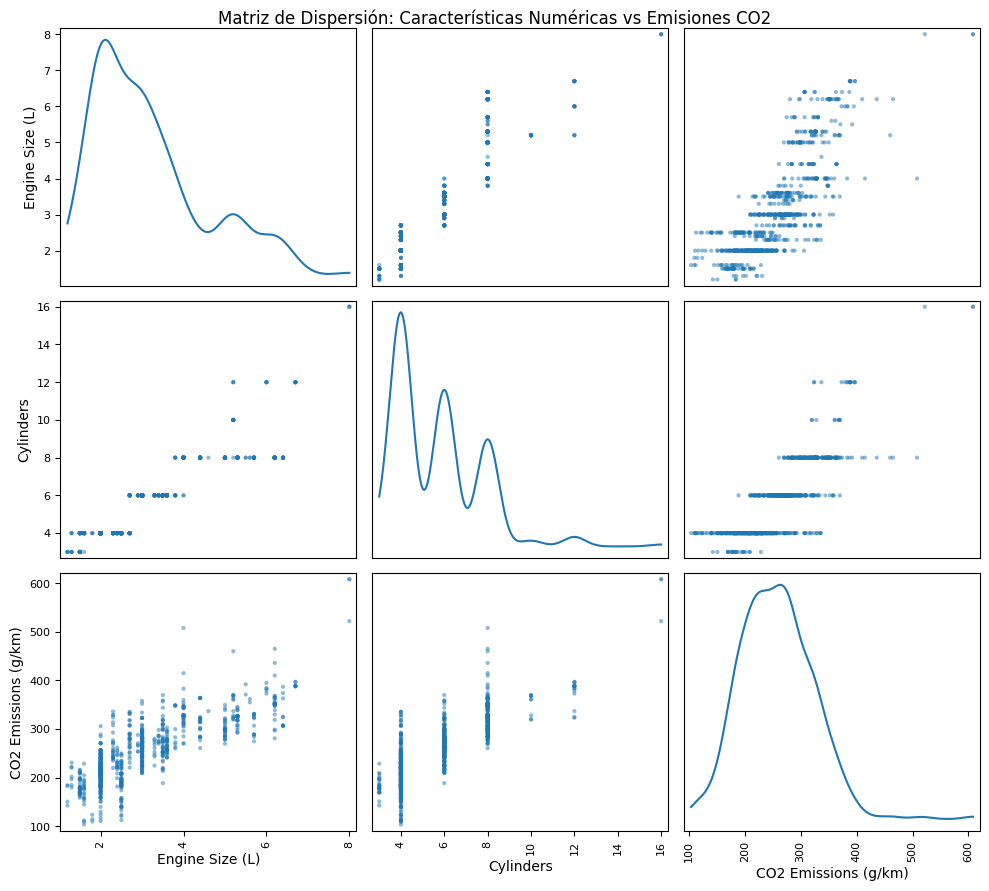

In [ ]:

try:

    columns_for_matrix = ['Engine Size (L)', 'Cylinders', 'CO2 Emissions (g/km)']
    print(f"Columnas seleccionadas para la nueva matriz: {columns_for_matrix}")

    df_subset = df[columns_for_matrix]

    print(f"Tamaño del subset ANTES de limpiar NaNs: {len(df_subset)} filas")
    df_subset_cleaned = df_subset.dropna()
    print(f"Tamaño del subset DESPUÉS de limpiar NaNs: {len(df_subset_cleaned)} filas")

    print("Generando la matriz de gráficos de dispersión (3x3)...")
    scatter_matrix = pd.plotting.scatter_matrix(df_subset_cleaned,
                                                figsize=(10, 10),
                                                diagonal='kde',
                                                alpha=0.5)

    plt.suptitle('Matriz de Dispersión: Características Numéricas vs Emisiones CO2', y=0.92)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

except FileNotFoundError:
    print("Error: El archivo 'Fuel Consumption Ratings 2023.csv' no se encontró.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

# ✨ Análisis de Resultados – Matriz de Dispersión ✨

🧠 Analizando los resultados obtenidos en la matriz de dispersión, nos podemos dar cuenta de que las relaciones que tienen las variables independientes con nuestra variable dependiente tienen una tendencia positiva.

⚙️ El tamaño del motor resulta ser un factor predictor importante:
➡️ A medida que aumenta el tamaño del motor, las emisiones de CO₂ tienden a aumentar de forma consistente.

🔢 Algo muy similar ocurre con los cilindros:
➡️ De forma general, a mayor número de cilindros, mayor emisión de CO₂ (aunque en este caso existe una mayor variabilidad).

📈 El gráfico también nos muestra que existe una relación positiva entre estas dos variables, es decir:
🔹 A mayor tamaño de motor, mayor número de cilindros.

📊 Las diagonales para el tamaño del motor y emisiones de CO₂ muestran que están sesgados hacia la derecha.
📌 En conclusión, la mayoría de vehículos tienen motores pequeños, por lo tanto, bajas emisiones de CO₂.



Tamaño del subset ANTES de limpiar NaNs: 856 filas
Tamaño del subset DESPUÉS de limpiar NaNs: 833 filas

Códigos de Tipo de Combustible y sus Significados
Código 'X': Gasolina Regular (Regular gasoline)
Código 'Z': Gasolina Premium (Premium gasoline)
Código 'D': Diésel (Diesel)
Código 'E': Etanol E85 (Ethanol E85)
Código 'N': Gas Natural (Natural gas)

Conteo de vehículos por tipo de combustible:
Fuel Type
Z    408
X    390
D     20
E     15
Name: count, dtype: int64


<ipython-input-6-39867252dc7e>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel Type', y='CO2 Emissions (g/km)', data=df_cleaned, palette='viridis')


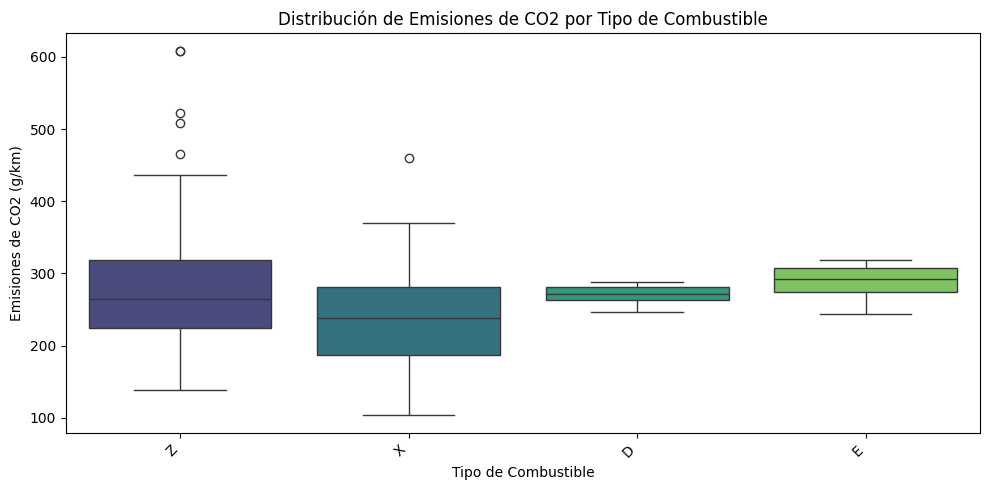

In [ ]:
try:

    columns_to_analyze = ['Fuel Type', 'CO2 Emissions (g/km)']
    df_subset = df[columns_to_analyze]
    print(f"\nTamaño del subset ANTES de limpiar NaNs: {len(df_subset)} filas")
    df_cleaned = df_subset.dropna()
    print(f"Tamaño del subset DESPUÉS de limpiar NaNs: {len(df_cleaned)} filas")

    fuel_type_codes = {
        'X': 'Gasolina Regular (Regular gasoline)',
        'Z': 'Gasolina Premium (Premium gasoline)',
        'D': 'Diésel (Diesel)',
        'E': 'Etanol E85 (Ethanol E85)',
        'N': 'Gas Natural (Natural gas)'
    }

    print("\nCódigos de Tipo de Combustible y sus Significados")
    for code, meaning in fuel_type_codes.items():
        print(f"Código '{code}': {meaning}")
    unique_fuel_types = df_cleaned['Fuel Type'].unique()
    print("\nConteo de vehículos por tipo de combustible:")
    print(df_cleaned['Fuel Type'].value_counts())
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Fuel Type', y='CO2 Emissions (g/km)', data=df_cleaned, palette='viridis')
    plt.title('Distribución de Emisiones de CO2 por Tipo de Combustible')
    plt.xlabel('Tipo de Combustible')
    plt.ylabel('Emisiones de CO2 (g/km)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: El archivo 'Fuel Consumption Ratings 2023.csv' no se encontró.")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

In [ ]:
print("\nEstadísticas descriptivas de Emisiones de CO2 por Tipo de Combustible:")
print(df_cleaned.groupby('Fuel Type')['CO2 Emissions (g/km)'].describe())




Estadísticas descriptivas de Emisiones de CO2 por Tipo de Combustible:
           count        mean        std    min     25%    50%    75%    max
Fuel Type                                                                  
D           20.0  270.400000  12.175904  247.0  263.75  272.0  281.0  288.0
E           15.0  287.200000  25.551628  244.0  274.00  293.0  308.0  318.0
X          390.0  237.510256  59.820113  104.0  187.00  238.0  281.0  460.0
Z          408.0  274.825980  65.329869  139.0  224.00  265.0  319.0  608.0


# 🚗 Análisis por Tipo de Combustible – Emisiones de CO₂ 🌿


💨 Los vehículos diseñados para Etanol E85 ('E') y Diésel ('D') tienden a ser los mayores emisores de CO₂ por kilómetro en este dataset.

⛽ Los vehículos de Gasolina ('X' y 'Z') cubren un rango amplio de emisiones:
🔹 Desde valores bastante bajos hasta valores altos,
🔹 Superponiéndose considerablemente entre Regular y Premium,
🔹 Aunque Premium tiende a asociarse con emisiones ligeramente más altas en promedio.

🌱 El Gas Natural ('N'), aunque con pocos datos, se posiciona como una alternativa con emisiones potencialmente más bajas o comparables a la gasolina regular.

# 3. Modelo de regresión: Emisiones de CO2 vs Tamaño del motor , Cilindros y Fuel Consumption



     Engine Size (L)  Cylinders  Fuel Consumption (L/100Km)  \
0                1.5        4.0                         7.9   
1                1.5        4.0                         8.1   
2                1.5        4.0                         8.9   
3                3.5        6.0                        12.6   
4                3.0        6.0                        13.8   
..               ...        ...                         ...   
828              2.0        4.0                        10.2   
829              2.0        4.0                        10.3   
830              2.0        4.0                        11.1   
831              2.0        4.0                        10.5   
832              2.0        4.0                        11.9   

     CO2 Emissions (g/km)  
0                   167.0  
1                   172.0  
2                   181.0  
3                   263.0  
4                   291.0  
..                    ...  
828                 215.0  
829                

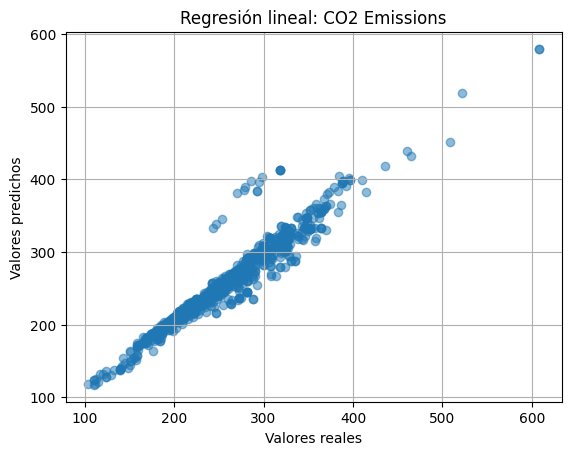

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

columns_regression = ['Engine Size (L)', 'Cylinders', 'Fuel Consumption (L/100Km)', 'CO2 Emissions (g/km)']
df_regression = df[columns_regression]
df_regression = df_regression.dropna()


X = df_regression.drop('CO2 Emissions (g/km)', axis=1)
y = df_regression['CO2 Emissions (g/km)']
model = LinearRegression()
model.fit(X, y)

print(df_regression)

y_pred = model.predict(X)


r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
print(f"R²: {r2:.3f}, MSE: {mse:.2f}")


plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Regresión lineal: CO2 Emissions")
plt.grid(True)
plt.show()



# 3.1 Cambiar las proporciones de los conjuntos


=== Modelo con split 70-30 ===
R² (Test): 0.929
MSE (Test): 253.10


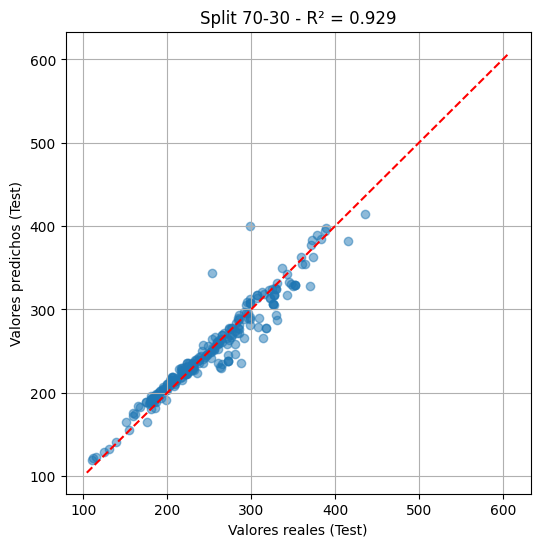


=== Modelo con split 50-50 ===
R² (Test): 0.918
MSE (Test): 295.88


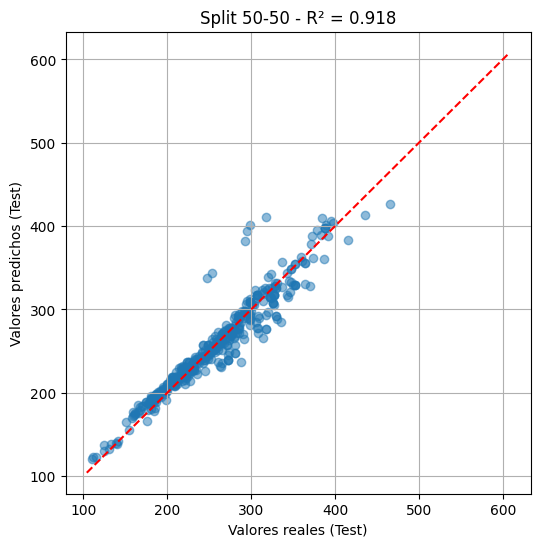


=== Modelo con split 40-60 ===
R² (Test): 0.913
MSE (Test): 320.11


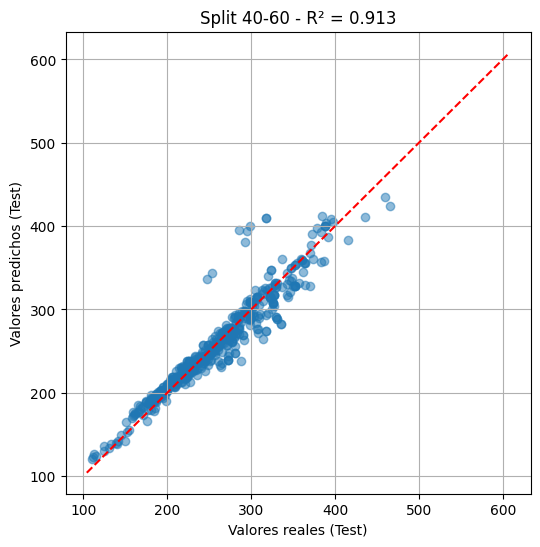

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

columns_regression = [
    'Engine Size (L)',
    'Cylinders',
    'Fuel Consumption (L/100Km)',
    'CO2 Emissions (g/km)'
]
df_regression = df[columns_regression].dropna()
X = df_regression.drop('CO2 Emissions (g/km)', axis=1)
y = df_regression['CO2 Emissions (g/km)']

splits = [
    {'test_size': 0.3, 'name': '70-30'},
    {'test_size': 0.5, 'name': '50-50'},
    {'test_size': 0.6, 'name': '40-60'},
]

for split in splits:
    print(f"\n=== Modelo con split {split['name']} ===")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=split['test_size'],
        random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"R² (Test): {r2:.3f}")
    print(f"MSE (Test): {mse:.2f}")
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Valores reales (Test)")
    plt.ylabel("Valores predichos (Test)")
    plt.title(f"Split {split['name']} - R² = {r2:.3f}")
    plt.grid(True)
    plt.show()

## Explicación
La proporción de datos de train-test afecta directamente en el ajuste del modelo, en este caso, al estar analizando la variable con solo un dataset de datos limitados, queremos que el ajuste sea lo mayor posible, por lo cual un mayor porcentaje de datos de entrenamiento nos va a dar un mejor resulado en R². Ahora bien, si quisieramos generalizar el modelo, probablemente necesitariamos cambiar la proporcion para tener mas datos de test.

# 3.2 Cambie el metodo de optimizacion, ej: Stochastic Gradient Descent

R² (SGD): 0.929, MSE (SGD): 254.97


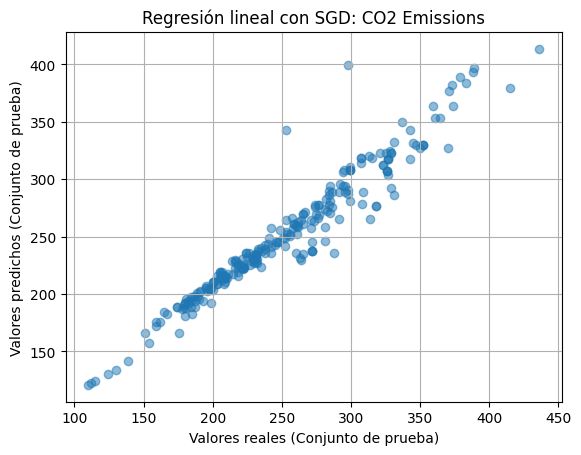

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

columns_regression = ['Engine Size (L)', 'Cylinders', 'Fuel Consumption (L/100Km)', 'CO2 Emissions (g/km)']
df_regression = df[columns_regression].copy()
df_regression = df_regression.dropna()
X = df_regression.drop('CO2 Emissions (g/km)', axis=1)
y = df_regression['CO2 Emissions (g/km)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd_model.fit(X_train_scaled, y_train)
y_pred_sgd = sgd_model.predict(X_test_scaled)
r2_sgd = r2_score(y_test, y_pred_sgd)
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
print(f"R² (SGD): {r2_sgd:.3f}, MSE (SGD): {mse_sgd:.2f}")
plt.scatter(y_test, y_pred_sgd, alpha=0.5)
plt.xlabel("Valores reales (Conjunto de prueba)")
plt.ylabel("Valores predichos (Conjunto de prueba)")
plt.title("Regresión lineal con SGD: CO2 Emissions")
plt.grid(True)
plt.show()

El modelo sí presentó cambios, en específico, el MSE (error cuadrático) fue menor, lo que quiere decir que tuvo mejores resultados a la hora de predecir

# Utilice un método de regularización
Utilizaremos regresión Ridge


R² (Ridge): 0.911, MSE (Ridge): 317.45
R² (Lineal): 0.929, MSE (Lineal): 253.10


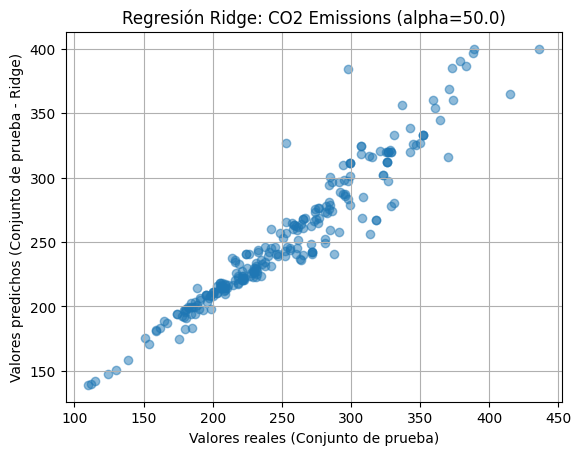

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd


columns_regression = ['Engine Size (L)', 'Cylinders', 'Fuel Consumption (L/100Km)', 'CO2 Emissions (g/km)']
df_regression = df[columns_regression].copy()
df_regression = df_regression.dropna()
X = df_regression.drop('CO2 Emissions (g/km)', axis=1)
y = df_regression['CO2 Emissions (g/km)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
alpha = 50.0
ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"R² (Ridge): {r2_ridge:.3f}, MSE (Ridge): {mse_ridge:.2f}")
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
y_pred_linear = linear_model.predict(X_test_scaled)
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
print(f"R² (Lineal): {r2_linear:.3f}, MSE (Lineal): {mse_linear:.2f}")
plt.scatter(y_test, y_pred_ridge, alpha=0.5)
plt.xlabel("Valores reales (Conjunto de prueba)")
plt.ylabel("Valores predichos (Conjunto de prueba - Ridge)")
plt.title(f"Regresión Ridge: CO2 Emissions (alpha={alpha})")
plt.grid(True)
plt.show()

La regresión ridge ayuda con el sobreajuste de este conjunto de datos, en este caso, ir reduciendo el parametro de lambda ayudaría a aumentar el sesgo, lo que produce una reducción en el ajuste. Sin embargo, hay que ser cuidadosos, aumentar mucho el lambda podría llevar a un subajuste, que tampoco es lo que queremos.

# 🎯 Selección de Modelo, Ajuste de Parámetros y Análisis de Resultados
División del dataset, elección de métodos y significado de los coeficientes

En este caso la mejor proporcion en la distribucion fue 70-30 (70% entrenamiento, 30% prueba). Esta proporción ofrece un buen balance entre ajuste y generalización, como se evidenció en las pruebas previas. Ademas, Stochastic Gradient Descent (SGD). Obtuvo un MSE menor en comparación con la Regresión Lineal, lo que indica una mejor minimización del error y el metodo de regularizacion Regresión Ridge. Con un valor alfa moderado, ayuda a prevenir el sobreajuste sin comprometer la complejidad del modelo

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# División 70-30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo Ridge
alpha = 10  # Regularización moderada
ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train_scaled, y_train)

# Parámetros
weights = ridge_model.coef_
intercept = ridge_model.intercept_

print("Pesos:", weights)
print("Intersección:", intercept)

Pesos: [-0.17455898  5.85130111 57.19098755]
Intersección: 260.04631217838767


**🔢Pesos:**

  📏Magnitud: Fuerza de la influencia de la variable independiente en las emisiones de CO2. Un peso mayor (valor absoluto) implica una influencia más fuerte.
  Signo:


* Positivo: La variable independiente tiene una relación directa con las emisiones de CO2. A medida que la variable aumenta, las emisiones también tienden a aumentar.
* Negativo: La variable independiente tiene una relación inversa con las emisiones de CO2. A medida que la variable aumenta, las emisiones tienden a disminuir.


    
**🎯Intersección:** Es el valor base de las emisiones de CO2 cuando todas las variables independientes son cero.

# 📊 Evaluación del Modelo: MSE y R² Score
Interpretación de métricas de desempeño

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = ridge_model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² score:", r2)

MSE: 262.27083274489496
R² score: 0.9266574082423206



🔢 **MSE (Mean Squared Error)**
 Representa el promedio de los errores al cuadrado entre las predicciones del modelo y los valores reales. Un MSE menor indica un mejor ajuste del modelo a los datos.

📈 **R² Score (Coeficiente de Determinación)**
Indica la proporción de la varianza en la variable dependiente que es explicada por el modelo. Un R² score más cercano a 1 indica un mejor ajuste, lo que significa que el modelo explica una mayor parte de la variabilidad en los datos.

🎯 **Objetivo del Modelo**
* Lograr un MSE bajo y un R² alto: Indica un modelo con buen ajuste a los datos y capaz de explicar adecuadamente la variabilidad de las emisiones de CO₂.



# ✅ Conclusiones del Análisis de Emisiones de CO₂ en Vehículos


## 1️⃣ **Relación entre Variables y Emisiones de CO₂**



🔹Los resultados del análisis exploratorio y del modelo de regresión confirman una fuerte correlación positiva entre el tamaño del motor, el número de cilindros y las emisiones de CO₂. Esta relación indica que, en general, a mayor tamaño del motor y número de cilindros, mayores son las emisiones de CO₂.
➡️ En general, a mayor tamaño del motor y número de cilindros, mayores son las emisiones.

⛽ El **tipo de combustible** también se ha identificado como un factor de gran influencia en las emisiones. Los vehículos que utilizan Etanol E85 y Diésel tienden a ser los mayores emisores de CO₂, mientras que el Gas Natural se posiciona como una alternativa con emisiones potencialmente más bajas, aunque con una muestra de datos limitada.

📊 Estas relaciones se evidencian en los gráficos de dispersión y diagramas de caja del análisis exploratorio.

## 2️⃣ **Predicción de Emisiones de CO₂**

🧠 El modelo de regresión lineal, construido con variables predictoras como el tamaño del motor, el número de cilindros y el consumo de combustible, ha demostrado una excelente capacidad explicativa, con un R² Score cercano a 1. Esto indica que el modelo es capaz de predecir con precisión las emisiones de CO₂ en función de las características del vehículo.

La elección del optimizador Stochastic Gradient Descent (SGD) y la aplicación de la regularización Ridge fueron claves para lograr un ajuste óptimo del modelo. El optimizador SGD permitió encontrar los parámetros del modelo que minimizan el error (MSE), mientras que la regularización Ridge ayudó a prevenir el sobreajuste, mejorando la capacidad del modelo para generalizar a nuevos datos. Estas decisiones se reflejan en las métricas de desempeño, con un MSE bajo y un R² alto, indicando un modelo preciso y con buen ajuste a los datos.


📌 Pesos del modelo:

* Peso positivo → Relación directa con las emisiones

* Peso negativo → Relación inversa

* Magnitud → Fuerza de la influencia

## 3️⃣ Implicaciones y Recomendaciones
🌱 Los resultados del análisis tienen implicaciones significativas para la sostenibilidad ambiental. Se ha demostrado que la elección del tamaño del motor, el número de cilindros y el tipo de combustible son decisiones cruciales para reducir las emisiones de CO₂ en el sector del transporte.

 Recomendaciones que podemos dar a partir de modelo:
**texto en negrita**
* Priorizar vehículos con motores más pequeños y menos cilindros: El modelo ha confirmado la influencia directa de estas características en las emisiones.
* Fomentar la adopción de combustibles más limpios: El Gas Natural, y en el futuro, otras alternativas como el hidrógeno, pueden contribuir a reducir significativamente la huella de carbono del transporte.
* Incentivar la investigación y desarrollo de tecnologías: La innovación tecnológica en motores, combustibles y sistemas de propulsión es esencial para lograr una movilidad más sostenible.

######🏭 Esta información es útil para:

* Los fabricantes de vehículos pueden utilizar esta información para diseñar vehículos más eficientes y sostenibles, priorizando la reducción de emisiones en sus estrategias de desarrollo.
* Los consumidores, a su vez, pueden tomar decisiones de compra más informadas, considerando el impacto ambiental de sus elecciones. La información sobre las emisiones de CO₂ debe ser accesible y transparente, permitiendo a los compradores comparar diferentes modelos y optar por opciones más ecológicas.
* En conjunto, la adopción de estas recomendaciones puede contribuir a la reducción de la huella de carbono del transporte y a la construcción de un futuro más sostenible.

Por ultimo, debemos tener en cuenta que este analisis es sobre un dataset en especifico y que estos resultados pueden variar.